<a href="https://colab.research.google.com/github/SathyaPrakashD/MachineLearning/blob/main/4_3_Precision_and_Recall_Customer_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 Confusion Matrix: Customer Churn Prediction

 **Course:** Machine Learning Zoomcamp | **Module 4:** Evaluation Metrics  
 **Dataset:** [Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn) (IBM Sample Data)  
 **Difficulty:** Beginner-Friendly

 ---

 ## What You Will Learn

 By the end of this notebook, you will be able to:

 - Understand **why accuracy alone can be misleading** for imbalanced classification problems
 - Build a **confusion matrix from scratch** using NumPy logical operations
 - Interpret all four cells of the confusion matrix — **TP, TN, FP, FN** — and understand the business cost of each
 - Evaluate a Logistic Regression model on the **Telco Customer Churn** dataset
 - Analyse how changing the **decision threshold** affects model accuracy

 ---

 ## Problem Overview

 A telecom company wants to predict which customers are likely to cancel their subscription (**churn**). By identifying at-risk customers early, the business can intervene with targeted offers or retention campaigns.

 **Target variable:** `churn` — 1 if the customer left, 0 if they stayed.

 ---

 ## Notebook Structure

 | Section | Description |
 |---|---|
 | **1. Setup & Imports** | Load libraries and the dataset |
 | **2. Data Preprocessing** | Clean and encode features |
 | **3. Train-Validation-Test Split** | Split data for unbiased evaluation |
 | **4. Model Training** | Fit a Logistic Regression classifier |
 | **5. Accuracy & The Dummy Model** | Explore the limits of accuracy as a metric |
 | **6. Confusion Matrix** | Build and interpret the confusion matrix |

 ---

 > **Prerequisites:** Basic Python, familiarity with pandas DataFrames, and a conceptual understanding of classification models. No prior knowledge of evaluation metrics is required.

## Section 1 — Setup & Imports

We begin by importing the core libraries needed for this notebook:

- **pandas** — for loading and manipulating tabular data
- **numpy** — for efficient numerical operations and array handling
- **matplotlib** — for visualising threshold vs. accuracy curves
- **scikit-learn** — for model training, feature encoding, and data splitting

In [ ]:
# Import the pandas library for data manipulation
import pandas as pd
# Import the numpy library for numerical operations
import numpy as np

# Import the matplotlib.pyplot library for plotting
import matplotlib.pyplot as plt

In [ ]:
# Import function to split data into training and testing sets
from sklearn.model_selection import train_test_split
# Import DictVectorizer for one-hot encoding categorical features
from sklearn.feature_extraction import DictVectorizer
# Import LogisticRegression for building the classification model
from sklearn.linear_model import LogisticRegression

In [ ]:
# Import the kagglehub library to access Kaggle datasets
import kagglehub

# Download the latest version of the dataset using kagglehub
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

# Print the path where the dataset files are located
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Path to dataset files: /kaggle/input/telco-customer-churn


## Section 2 — Data Loading & Preprocessing

The raw dataset contains **7,043 rows and 21 columns**. Before training a model, we need to:

1. **Standardise column names** — convert to lowercase and replace spaces with underscores for consistent access
2. **Normalise string values** — apply the same formatting to text values in categorical columns
3. **Fix the `TotalCharges` column** — this column is stored as a string; we coerce it to numeric, filling any gaps with `0`
4. **Encode the target variable** — convert `churn` from `"yes"/"no"` to binary `1/0`

> **Beginner tip:** These steps are called *data preprocessing* or *data cleaning*. Real-world datasets are rarely ready to use straight out of the box — formatting inconsistencies are very common.

In [ ]:
# Import the pandas library for data manipulation
import pandas as pd

# Read the CSV file into a pandas DataFrame
df = pd.read_csv(path + "/WA_Fn-UseC_-Telco-Customer-Churn.csv")
# Display the DataFrame to show its contents
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [ ]:
# Convert column names to lowercase and replace spaces with underscores
df.columns = df.columns.str.lower().str.replace(' ', '_')

# Identify categorical columns (object dtype)
categorical_columns = list(df.dtypes[df.dtypes == 'object'].index)
for c in categorical_columns:
  # Convert values in categorical columns to lowercase and replace spaces with underscores
    df[c] = df[c].str.lower().str.replace(' ', '_')

# Convert 'totalcharges' to numeric, coercing errors to NaN
df.totalcharges = pd.to_numeric(df.totalcharges, errors='coerce')
# Fill any missing 'totalcharges' values with 0
df.totalcharges = df.totalcharges.fillna(0)
# Convert 'churn' column from 'yes'/'no' to 1/0 integers
df.churn = (df.churn == 'yes').astype(int)

## Section 3 — Train / Validation / Test Split

We divide the data into **three** non-overlapping subsets. This is a standard best practice in machine learning to prevent *data leakage* and ensure the final evaluation is unbiased.

| Split | Size | Purpose |
|---|---|---|
| **Training set** (`df_train`) | 60% of total | Used to fit the model |
| **Validation set** (`df_val`) | 20% of total | Used to tune and evaluate the model during development |
| **Test set** (`df_test`) | 20% of total | Held out completely — used only for final evaluation |

The split is achieved in two steps:
- First, we split off 20% as the test set (`df_full_train` + `df_test`)
- Then we split `df_full_train` 75/25 to get the training and validation sets

> **Why three splits?** The validation set is used to make modelling decisions (e.g. choosing a threshold). If we used the test set for this, we would be "peeking" at the data and our final accuracy estimate would be overly optimistic.

In [ ]:
# Split data into full training (80%) and test (20%) sets
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
# Split full training into training (75% of full train) and validation (25% of full train) sets
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

# Reset index for training DataFrame
df_train = df_train.reset_index(drop=True)
# Reset index for validation DataFrame
df_val = df_val.reset_index(drop=True)
# Reset index for test DataFrame
df_test = df_test.reset_index(drop=True)

# Extract 'churn' target variable for training set
y_train = df_train.churn.values
# Extract 'churn' target variable for validation set
y_val = df_val.churn.values
# Extract 'churn' target variable for test set
y_test = df_test.churn.values

# Remove 'churn' column from training features
del df_train['churn']
# Remove 'churn' column from validation features
del df_val['churn']
# Remove 'churn' column from test features
del df_test['churn']

## Section 4 — Feature Engineering & Model Training

### Feature Selection

We use a mix of **numerical** and **categorical** features:

- **Numerical features:** `tenure`, `monthlycharges`, `totalcharges` — these are already numbers and can be fed directly into the model
- **Categorical features:** `gender`, `contract`, `internetservice`, etc. — these are text values that need to be *encoded* into numbers

### Encoding with DictVectorizer

`DictVectorizer` converts each row into a dictionary and then applies **one-hot encoding** to categorical features. This means each unique text value gets its own binary (0/1) column.

> **Beginner tip:** Machine learning models work with numbers, not text. One-hot encoding is a common technique to convert categorical values into a format the model can understand.

### Logistic Regression

We use **Logistic Regression** — a simple but powerful algorithm for binary classification. Despite its name, it is a *classification* model, not a regression model. It outputs a probability between 0 and 1, which we then threshold to make a class prediction.

In [ ]:
# Define list of numerical features
numerical = ['tenure', 'monthlycharges', 'totalcharges']

# Define list of categorical features
categorical = [
    'gender',
    'seniorcitizen',
    'partner',
    'dependents',
    'phoneservice',
    'multiplelines',
    'internetservice',
    'onlinesecurity',
    'onlinebackup',
    'deviceprotection',
    'techsupport',
    'streamingtv',
    'streamingmovies',
    'contract',
    'paperlessbilling',
    'paymentmethod',
]

In [ ]:
# Initialize DictVectorizer for one-hot encoding, ensuring dense output
dv = DictVectorizer(sparse=False)

# Convert training data features to a list of dictionaries
train_dict = df_train[categorical + numerical].to_dict(orient='records')
# Fit DictVectorizer and transform training data
X_train = dv.fit_transform(train_dict)

# Initialize Logistic Regression model
model = LogisticRegression()
# Train the Logistic Regression model using the transformed training features and target variable
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

This code block calculates the predicted probabilities of churn for the validation set and then converts these probabilities into binary churn decisions based on a 0.5 threshold.

*   `y_pred = model.predict_proba(X_val)[:, 1]`: This line uses the trained `model` to predict the probability of churn for each customer in the `X_val` (validation) dataset. `predict_proba()` returns probabilities for both classes, and `[:, 1]` selects only the probabilities for the positive class (churn).
*   `churn_decision = (y_pred >= 0.5)`: This line converts the predicted probabilities into a binary decision. If a customer's churn probability (`y_pred`) is 0.5 or higher, `churn_decision` for that customer will be `True` (predicted to churn); otherwise, it will be `False` (predicted not to churn). This operation is element-wise, meaning the `churn_decision` array has the same length as `y_pred` and `y_val`.

In [ ]:
# Convert validation data features to a list of dictionaries
val_dict = df_val[categorical + numerical].to_dict(orient='records')
# Transform validation data using the fitted DictVectorizer
X_val = dv.transform(val_dict)

# Get predicted probabilities for the positive class (churn=1) on the validation set
y_pred = model.predict_proba(X_val)[:, 1]
print(y_pred.round(3))
print(len(y_pred))

# Classify as churn if probability is 0.5 or higher
churn_decision = (y_pred >= 0.5)
print(len(churn_decision))

# Calculate the accuracy of the model on the validation set
(y_val == churn_decision).mean()

[0.008 0.21  0.224 ... 0.15  0.777 0.81 ]
1409
1409


np.float64(0.801277501774308)

## Section 5 — Accuracy & the Dummy Model

### Step 1: Generate Predictions

The trained model outputs a **probability score** between 0 and 1 for each customer. We then convert this into a binary prediction using a **threshold**:

- If the score ≥ threshold → predict **churn** (1)
- If the score < threshold → predict **no churn** (0)

The default threshold is **0.5**, but we will explore whether other values perform better.

### Step 2: Evaluate Accuracy Across Thresholds

We sweep thresholds from 0 to 1 using `np.linspace` and record the accuracy at each step. This tells us whether the 0.5 default is actually optimal.

### Step 3: The Dummy Model Problem

A **dummy model** that *always* predicts "no churn" achieves **~73% accuracy** — simply because 73% of customers in this dataset did not churn. This exploits the natural class imbalance in the data.

Our trained Logistic Regression model achieves **~80% accuracy** — only 7 percentage points better than doing nothing.

> **Key insight:** This is the core limitation of accuracy as a metric for imbalanced datasets. A model that never identifies churners correctly could still score 73%. Accuracy alone cannot tell us how well the model detects the minority class (churners), or what type of mistakes it is making. This is why we need the **Confusion Matrix**.

In [ ]:
len(y_val)

1409

This line calculates the accuracy of the model on the validation set.

*   `(y_val == churn_decision)`: This performs an element-wise comparison between the actual churn values (`y_val`, which are 0s and 1s) and the model's predicted churn decisions (`churn_decision`, which are True/False). It creates a new boolean array where `True` indicates a correct prediction and `False` indicates an incorrect prediction.
*   `.mean()`: When applied to a boolean array, `.mean()` treats `True` as 1 and `False` as 0. Therefore, the result is the proportion of `True` values, which represents the overall accuracy of the model.

In [ ]:
(y_val == churn_decision).mean()

np.float64(0.801277501774308)

This line calculates the total number of correct predictions made by the model on the validation set.

*   `(y_val == churn_decision)`: Similar to the accuracy calculation, this creates a boolean array where `True` indicates a correct prediction and `False` an incorrect one.
*   `.sum()`: When applied to a boolean array, `.sum()` treats `True` as 1 and `False` as 0. Therefore, the result is the total count of `True` values, representing the absolute number of correct predictions.

In [ ]:
(y_val == churn_decision).sum()

np.int64(1129)

In [ ]:
1129/1409

0.801277501774308

This is the accuracy. total number of correct prediction divided by total number of prediction in y_val.

The decision threshold is set to **0.5**: a customer is classified as churning if their predicted probability is 0.5 or higher.

```python
churn_decision = (y_pred >= 0.5)
```

Let's explore whether increasing or decreasing the threshold from 0.5 improves model accuracy.

Lets create a array of threshold using linspace.

In [ ]:
We create an array of 21 evenly-spaced threshold values between 0 and 1 using `np.linspace(0, 1, 21)`.

SyntaxError: invalid syntax (3485717820.py, line 1)

Lets iterate over array of thresholds

In [ ]:
scores = []

for t in thresholds:
  churn_decision = (y_pred >= t)
  score = (y_val == churn_decision).mean()
  scores.append(score)
  #print(t, "-- " ,(y_val == churn_decision).mean())
  print('%.2f %.3f' % (t,score))


0.00 0.274
0.05 0.509
0.10 0.598
0.15 0.664
0.20 0.707
0.25 0.737
0.30 0.759
0.35 0.766
0.40 0.780
0.45 0.793
0.50 0.801
0.55 0.798
0.60 0.797
0.65 0.784
0.70 0.765
0.75 0.744
0.80 0.730
0.85 0.726
0.90 0.726
0.95 0.726
1.00 0.726


From the above the output we see  that 0.5 is infact the best threshold

**0.5 - 0.801**

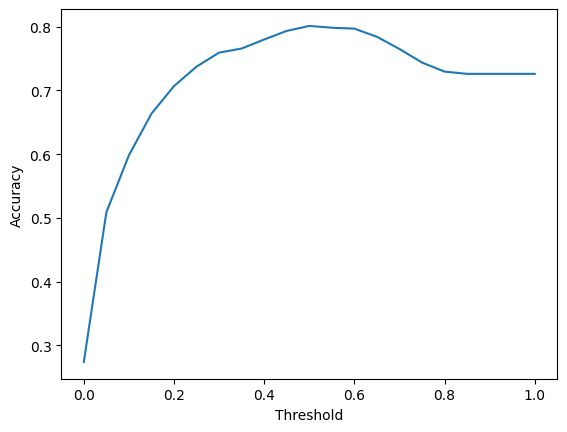

In [ ]:
plt.plot(thresholds, scores)
plt.xlabel('Threshold')
plt.ylabel('Accuracy')
plt.show()
#

- Above graph tells that there is no customer churns for Threashold above 1.0.

- For a model with threshold = 1.0 has the accuracy of 73%.

Important question to observe.

- A Dummy model with threshold greater or equal to 1.0 has a accuracy of 0.73 or 73% and the above trained model has a accuracy of 80%.

- **Why do we need to train the model for only 7% difference in performance**

  - This is the main issue with Accuracy. Accuracy doesn't tell us about the performance of the model.

  - As per the class distribution in the data only 27% of the users are churning and remaining 73% are non-chruning. So there is almost 3:1 class imbalance between churning and non-chruning users.

# Confusion Table

 - Different types of errors and correct decisions.
 - Arranging them in table

In [ ]:
actual_postives = (y_val == 1)
actual_negatives = (y_val == 0)

In [ ]:
t = 0.5
predicted_positives = (y_pred >= t)
predicted_negatives = (y_pred < t)


**True Positive = Predicted Postives and Actual postives**

In [ ]:
tp = (predicted_positives & actual_postives).sum()
tp

np.int64(214)

**True Negatives = Predicted Negatives and Actual Negatives**

In [ ]:
tn = (predicted_negatives & actual_negatives).sum()
tn

np.int64(915)

**False Postives = Predicted Postive and actual Negative**

In [ ]:
fp = (predicted_positives & actual_negatives).sum()
fp

np.int64(108)

**False Negatives = Predicted Negative and Actual Negative**

In [ ]:
fn = (predicted_negatives & actual_postives).sum()
fn

np.int64(172)

In [ ]:
tp,tn,fp,fn,(tp+tn+fp+fn),len(y_val)

(np.int64(214),
 np.int64(915),
 np.int64(108),
 np.int64(172),
 np.int64(1409),
 1409)

**Confusion matrix**

In [ ]:
confusion_matrix = np.array([
    [tn,fp],
    [fn,tp]
])

confusion_matrix

array([[915, 108],
       [172, 214]])

In [ ]:
confusion_matrix = np.array([
    [tn,fp],
    [fn,tp]
])

(confusion_matrix / confusion_matrix.sum()).round(3)

array([[0.649, 0.077],
       [0.122, 0.152]])